# Testing out Point Defects
Schottky defect

## Testing Point Defects in Ice using ECM

### Generate ice block of appropriate size.

In [78]:
from jax.lax import switch
from tracemalloc import stop
import os
from typing import Literal
from ase.io import read, write
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
import numpy as np
import veloxchem.ensembledriver
import veloxchem.ensembleparser
import pandas as pd

#from pymodule.ECM_test.tempfiles.main import PDB_FILE, QM_RESNAME

PATH = 'tempfiles'

CHARGE_MAP = {'O': 2, 'C': 0, 'H': -1, 'Na': 1, 'Cl': -1}
    
ATOMIC_NUMBERS = {
    'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8,
    'F': 9, 'Ne': 10, 'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15,
    'S': 16, 'Cl': 17, 'Ar': 18, 'K': 19, 'Ca': 20,
}

PossiblePhases = Literal['1h', '1c']    
def generate_ice_block(path, phase: PossiblePhases, cell_dimensions, unit_cell_filename, target_supercell_shape, target_supercell_size, write_to_pdb = True, plot = True):
    super_cell_filename = f'{phase}x{cell_dimensions[0]}{cell_dimensions[1]}{cell_dimensions[2]}_supercell'
    # Generate unit.
    os.system(f'mkdir {path}')
    # os.system('ls')
    os.system(f'genice2 --rep {cell_dimensions[0]} {cell_dimensions[1]} {cell_dimensions[2]} {phase} --format cif > {path}/{unit_cell_filename}.cif')

    # Make Atoms obj. 
    ice = read(
        filename=(f'{path}/{unit_cell_filename}.cif')
        )

    # print(np.asarray(cell))
    P = find_optimal_cell_shape(
        cell=ice.cell, 
        target_size=target_supercell_size,
        target_shape=target_supercell_shape
        )

    ice_block = make_supercell(prim=ice,P=P,)
    
    if write_to_pdb:
        pdb_file = f'{path}/{super_cell_filename}.pdb'
        write(f'{pdb_file}', ice_block)
    
    if plot:
        plot_atoms(ice_block)

# TODO: Generalize this function to output more geometry parameters if necessary
def get_space_dimensions(filename = None, ):
    
    supercell = read(f'{filename}')
    np_supercell = np.array(supercell)

    x = 0
    y = 0
    z = 0
    for i in np_supercell:
        ix, iy, iz = i.position
        if ix > x:
            x = ix
        if iy > y:
            y = iy
        if iz > z:
            z = iz
        print(ix)
    # print(x, y, z)
    return [x, y, z]

# TODO: Simplify to output all indecies in QM region. 
def get_centeroid_region(filename, patterns, cuboid_threshold=None, print_ctrl=True):
    '''
    Returns dict mapping resnames to lists of atom indices within the QM cuboid region.
    
    Args:
        filename:          Path to pdb or cif file.
        patterns:          Dict mapping resname to symbol pattern, 
                           e.g. {'WAT': ['O', 'H', 'H'], 'ION': ['Na']}
        cuboid_threshold:  Decimal margin from center to edge of cuboid QM region.
        print_ctrl:        Print real-time status.
    
    Returns:
        Dict like {'WAT': [3, 15, 27], 'ION': [5]} — starting atom indices per resname.
    '''
    supercell = read(f'{filename}')
    x, y, z = get_space_dimensions(filename)
    
    midpoint = [x/2, y/2, z/2]
    x_threshold = [(midpoint[0] - x * cuboid_threshold), (midpoint[0] + x * cuboid_threshold)]
    y_threshold = [(midpoint[1] - y * cuboid_threshold), (midpoint[1] + y * cuboid_threshold)]
    z_threshold = [(midpoint[2] - z * cuboid_threshold), (midpoint[2] + z * cuboid_threshold)]

    symbols = list(supercell.symbols)
    qm_candidates = {}

    for resname, pattern in patterns.items():
        candidates = []
        matches = _find_pattern(symbols=symbols, pattern=pattern) # output inital indecies of matched segments in list of symbols. 
        print(f'Checked pattern {pattern}, for residuename {resname}')
        print(f'Found the following indecies {matches}')
        for i in matches: # Checks each given index
            atom = supercell[i]
            ax, ay, az = atom.position  # check position of the first atom
            if (ax < x_threshold[0] or ax > x_threshold[1] or
                ay < y_threshold[0] or ay > y_threshold[1] or
                az < z_threshold[0] or az > z_threshold[1]):
                continue
            candidates.append(atom.index)
            candidates.append(atom.index+1)
            candidates.append(atom.index+2)
        qm_candidates[resname] = candidates

        if print_ctrl:
            print(f'Pattern {resname} {pattern}: {len(matches)} total, {len(candidates)} in QM region')

    return qm_candidates

def process_pdb(filename, patterns, qm_ids=None, qm_resname=None):
    """
    Process a PDB file, assigning residue names and unique residue numbers
    to atoms matching specified patterns.

    Args:
        filename:   Path to the PDB file.
        patterns:   Dict mapping residue names to atom symbol patterns.
                    e.g. {'WAT': [' O', ' H', ' H'], 'ION': [' Na']}
        qm_ids:     Optional list of atom indices whose residue name
                    should be overridden with qm_resname.
        qm_resname: Residue name for QM-region molecules (e.g. 'LIG').
    """
    if qm_ids is None:
        qm_ids = {}

    print(f'Processing {filename}')
    with open(filename) as f:
        lines = f.readlines()

    # Identify ATOM data region
    start_idx = None
    end_idx = None
    for i, line in enumerate(lines):
        if line.startswith('ATOM'):
            if start_idx is None:
                start_idx = i
            end_idx = i

    if start_idx is None:
        print('No ATOM lines found.')
        return

    print(f'Data row index limits: Start: {start_idx}; End: {end_idx}')

    # Extract atom symbols from the ATOM region
    symbols = [line[14:16] for line in lines[start_idx:end_idx + 1]]

    # Find all matching segments for every pattern
    matches = []  # (line_index, pattern_length, resname)
    for resname, pattern in patterns.items():
        for idx in _find_pattern(symbols, pattern, offset=start_idx):
            matches.append((idx, len(pattern), resname))

    # Sort by line index so residue numbers are assigned in file order
    matches.sort(key=lambda x: x[0])
    print(f'Found {len(matches)} matching segments.')
    print(f'-> \t{matches}')

    # Assign residue names and unique residue numbers
    print(f'Lines before residue reassignments: {lines}')
    res_num = 2
    for seg_idx, pat_len, resname in matches:
        print(f'DOING {resname} at segment with index {seg_idx} with pattern length {pat_len}')
        res_num_str = f'{res_num:>4}'
        residue_name = resname
        # Check if this segment's index is in the QM list for its resname
        if qm_resname is not None and (seg_idx-start_idx) in qm_ids.get(resname, []):
            residue_name = qm_resname
        for i in range(pat_len):
            line = lines[seg_idx + i]
            lines[seg_idx + i] = line[:17] + residue_name + line[20:22] + res_num_str + line[26:]
        res_num += 1

    with open(filename, 'w') as f:
        f.writelines(lines)
    print(f'Lines after residue reassignments:  {lines}')

    print(f'Done. Assigned {res_num - 2} residues.')


def _find_pattern(symbols, pattern, offset=0):
    """
    Find all non-overlapping occurrences of pattern in symbols.
    Returns a list of absolute line indices (adjusted by offset).
    """
    matches = []
    i = 0
    while i <= len(symbols) - len(pattern):
        if symbols[i:i + len(pattern)] == pattern:
            matches.append(i + offset)
            i += len(pattern)  # skip past this match to avoid overlap
        else:
            i += 1
    return matches

def minimum_image_unwrap(filename):
    """
    Unwrap molecules split across periodic boundaries in a PDB file.
    For each residue, shifts all atoms to be within half a cell length
    of the first atom in that residue (the minimum image convention).
    
    Must be called AFTER process_pdb has assigned correct residue numbers.
    Modifies the file in place.
    """
    with open(filename) as f:
        lines = f.readlines()

    # Extract cell dimensions from the CRYST1 record
    cell = None
    for line in lines:
        if line.startswith('CRYST1'):
            cell = [float(line[6:15]), float(line[15:24]), float(line[24:33])]
            break

    if cell is None:
        print('No CRYST1 record found. Cannot unwrap.')
        return

    # Group ATOM lines by (chain ID, residue number)
    residues = {}
    for i, line in enumerate(lines):
        if line.startswith('ATOM') or line.startswith('HETATM'):
            key = line[21:26]  # chain ID + residue seq number
            if key not in residues:
                residues[key] = []
            residues[key].append(i)

    # For each residue, unwrap atoms relative to the first atom
    n_fixed = 0
    for key, atom_indices in residues.items():
        if len(atom_indices) < 2:
            continue

        # Reference position = first atom in the residue (e.g. the Oxygen)
        ref_line = lines[atom_indices[0]]
        ref_pos = [float(ref_line[30:38]), float(ref_line[38:46]), float(ref_line[46:54])]

        for idx in atom_indices[1:]:
            line = lines[idx]
            pos = [float(line[30:38]), float(line[38:46]), float(line[46:54])]
            fixed = False

            for ax in range(3):
                diff = pos[ax] - ref_pos[ax]
                if diff > cell[ax] / 2:
                    pos[ax] -= cell[ax]
                    fixed = True
                elif diff < -cell[ax] / 2:
                    pos[ax] += cell[ax]
                    fixed = True

            if fixed:
                lines[idx] = line[:30] + f'{pos[0]:8.3f}{pos[1]:8.3f}{pos[2]:8.3f}' + line[54:]
                n_fixed += 1

    with open(filename, 'w') as f:
        f.writelines(lines)

    print(f'Unwrapped {n_fixed} atoms across {len(residues)} residues in {filename}.')
    
# TODO: output new candidate list
def del_atoms_pdb(filename, qm_resname, output_filename, delete_indecies):
    defect = read(filename)[delete_indecies]
    # Extract each line in the file. 
    with open(filename) as f:
        lines = f.readlines()

    # Itterate and processes relevant lines. 
    old_atom_index = 0
    new_index = 1

    new_qm_candidates = []  # Save new QM atom candidates here.
    i = 0                   # Track lines line index.
    out = lines.copy()     # Copy original lines list to output list. To be modified... 
    offset = 0
    for i, line in enumerate(lines):
        # print(f'--> ENTERING LINE: {line} \nCURRENT OUTPUT LINE: {out[i-offset]} ')
        if line.startswith('ATOM') == False:
            continue

        if old_atom_index in delete_indecies:       # Check if atom of current line is in target ids. 
            del out[i-offset]                                                         # If yes, delete the line from output list. This should switch the entries in the output list up. 
            offset += 1
        if old_atom_index not in delete_indecies:   # Check if atom of current line is not in target ids.
            # Updated line index
            new_index_str = str(new_index).rjust(4)
            out[i-offset] = line[:7] + new_index_str + line[11:]                       # Insert the updated atom index in the atom index columns of the pdb line. 
            # print(f'APPENDED LINE: {out[i]}')
            # Update qm candidate list
            if line[17:20] == qm_resname:                                       # Check the ligand name of the current name between at the specified columns. 
                # print(f'Atom in QM region found at index {new_index}')          
                new_qm_candidates.append(new_index)                             # Append the index the new qm candidates list. 
            new_index += 1

        old_atom_index +=1
        # Go to next line and observe the respective (old) atom index.
        
        #i += 1                                                                  # Itterate the global loop index. 
    
    with open(output_filename, 'w') as f:
        f.writelines(out)
    return defect, new_qm_candidates

def calc_charge_multiplicity(filename, qm_resname, charge_map, atomic_numbers=ATOMIC_NUMBERS):
    """
    Calculate the net formal charge and spin multiplicity of the QM region
    by reading the PDB and identifying QM atoms by their residue name.

    This approach is robust to atom deletions (defect cells) because it
    relies on residue labels baked into the PDB, not on atom indices.

    Args:
        filename:     Path to the PDB file.
        qm_resname:   Residue name used for QM region (e.g. 'LIG').
        charge_map:   Dict mapping atom symbols to formal charges,
                      e.g. {'Na': 1, 'Cl': -1, 'O': -2, 'H': 1}

    Returns:
        tuple: (qm_charge, qm_multiplicity)
            - qm_charge (int): Net formal charge of the QM region.
            - qm_multiplicity (int): Spin multiplicity (1 = singlet, 2 = doublet, ...).
              Assumes lowest-spin ground state: even electrons → 1, odd → 2.
    """
    qm_charge = 0
    total_electrons = 0

    with open(filename) as f:
        for line in f:
            if line.startswith('ATOM') or line.startswith('HETATM'):
                resname = line[17:20].strip()
                if resname == qm_resname:
                    # Extract element symbol from cols 76-78 (standard PDB)
                    symbol = line[76:78].strip()
                    qm_charge += charge_map.get(symbol, 0)
                    total_electrons += atomic_numbers.get(symbol, 0)

    # Actual electron count = nuclear electrons minus net charge
    # (positive charge means fewer electrons, negative means more)
    actual_electrons = total_electrons - qm_charge

    # Lowest-spin assumption: even e⁻ → singlet (1), odd e⁻ → doublet (2)
    qm_multiplicity = 1 if actual_electrons % 2 == 0 else 2

    return qm_charge, qm_multiplicity

def calc_ernergy_fermi(filename):
    return

def calc_pot(filename):
    return


def calc_energy_tot(filename, qm_resname, pe_cutoff=6.0, npe_cutoff=None, qm_charge=0, qm_multiplicity=1):
    print("Ensemble parser instance created.")
    ep = veloxchem.ensembleparser.EnsembleParser()   
    ed = veloxchem.ensembledriver.EnsembleDriver()
    
    ensemble = ep.structures(
        trajectory_file = f"{filename}",
        num_snapshots = None, 
        qm_region = f"resname {qm_resname}", 
        pe_cutoff = pe_cutoff,
        npe_cutoff=npe_cutoff
    )

    ed.set_env_models(pe_model = 'SEP', npe_model='tip3p')

    # TODO: Testa att sätta ed.xcfun = 'B3LYP'

    scf_results = ed.compute(ensemble, basis_set = '6-31G', qm_charge=qm_charge, qm_multiplicity=qm_multiplicity)
    return scf_results

def calc_formation_energy(filename_perf, filename_defect, defect, qm_resname, atom_potentials, defect_type = 'molecular', molecule_len = 0, pe_cutoff = None, npe_cutoff = None, charge_map=CHARGE_MAP):
    '''
    params
        filename_perf: path to pdb of complete crystal.
        filename_defect: path to pdb of defect crystal.
        defect: ase.atoms object holding the unit cell conainig vacated atoms. 
        qm_resname: three char string of qm specfici residue name.
        atom_potentials: dictionary of precalcualted atom potentials.

    '''
    # clac total energy of complete crystal
    print(f'1.\tCALCULATING PERFECT LATTICE CHARGE AND MULTIPLICITY')
    charge_perf, multiplicity_perf= calc_charge_multiplicity(filename=filename_perf, qm_resname=qm_resname, charge_map=charge_map)
    print(f'  \tCharge: {charge_perf}\n  \tMultiplicity: {multiplicity_perf}')

    print(f'2.\tCALCULATING TOTAL ENERGY OF PERFECT LATTICE')
    tot_energy_perf = calc_energy_tot(
        filename=filename_perf, 
        qm_resname=qm_resname, 
        pe_cutoff=pe_cutoff, 
        npe_cutoff=npe_cutoff, 
        qm_charge=charge_perf,
        qm_multiplicity=multiplicity_perf 
        )
    tot_energy_perf = tot_energy_perf['scf_all'][0][1]['scf_energy']
    print(f'  \tTotal energy: {tot_energy_perf} (perfect)')
    
    # calc total energy of defect crystal
    print(f'3.\tCALCULATING DEFECT LATTICE CHARGE AND MULTIPLICITY')
    charge_defect, multiplicity_defect = calc_charge_multiplicity(filename=filename_defect, qm_resname=qm_resname, charge_map=charge_map)
    print(f'3.\tCharge: {charge_defect}\n  \tMultiplicity: {multiplicity_defect}')

    print(f'4.\tCALCULATING TOTAL ENERGY OF DEFECT LATTICE')
    tot_energy_defect = calc_energy_tot(
        filename=filename_defect,
        qm_resname=qm_resname,
        pe_cutoff=pe_cutoff, 
        npe_cutoff=npe_cutoff, 
        qm_charge=charge_defect,
        qm_multiplicity=multiplicity_perf
        )
    tot_energy_defect = tot_energy_defect['scf_all'][0][1]['scf_energy'] # NOTE: HERE sExtract only energy from the sfc results:
    print(f'4.\tTotal energy: {tot_energy_defect} (defect)')

    # Print Summary
    print(f'STAGE SUMMAR:\n\tPerfect lattice energy: {tot_energy_perf} Hartree\n\tDefect lattice energy: {tot_energy_defect} Hartree\n\tEnergy diff. (Def-Perf): {tot_energy_defect-tot_energy_perf} Hartree')
    
    # calc chemcial potential of vacant atoms
    print(f'5. \tDETERMINING TOTAL CHEMCIAL POTENTIAL')
    # vacancy = np.array(defect)
    chem_pot = 0

    if defect_type == 'molecular' and molecule_len > 0:
        n_i = -1 * len(defect)/molecule_len
        chem_pot = tot_energy_defect/n_i

    # print(f'5.1\t\tCounting atoms per typs:')
    # atom_count = {}
    # for a in vacancy:
    #     if a.symbol in atom_count:
    #         atom_count[a.symbol] += 1
    #     atom_count[a.symbol] = 1
     
    # symbols = atom_count.keys()
    # for symb in symbols:
    #     n = atom_count[symb]
    #     mu = atom_potentials[symb]
    #     formation_energy += (n*mu)

    # acccount for the fermi level when charge is ≠ 0
    # if charge_defect != 0:
    #     # . . .
    #     # add fermi level addition
    #     # . . . 
    #     return formation_energy
    print(f'5.\tChemcial potential: {chem_pot}')
    print(f'6.\tFORMATION ENERGY:')
    formation_energy = tot_energy_defect-tot_energy_perf+chem_pot
    print(f'  \tE_F = {formation_energy} Hartree')
    return formation_energy

    

In [ ]:
# import ase

# test = read(filename='tempfiles/1hx111.cif')

# test = np.array(test)

# test[0].symbol

dict = {'F': 1, 'K': 3}
list = [1,2,3,4,5,6]
list2 = [3,4,5,6,7,8]
if 'f' in dict:
    print(True)

else:
    print(False)
dict['U'] = 1

#print(dict)
keys = dict.keys()

for i in keys:
    print(i)

for val, val2 in zip(keys, list2):
    print(val, val2)



#plot_atoms(test)



Specify some general parameters

In [2]:
UNIT_CELL_DIMENSIONS = (2,1,1)

GENERAL_FILE_NAME = f'1hx{UNIT_CELL_DIMENSIONS[0]}{UNIT_CELL_DIMENSIONS[1]}{UNIT_CELL_DIMENSIONS[2]}'
# SUPERCELL_FILE_NAME = f'{GENERAL_FILE_NAME}_supercell'
PDB_FILE = f'{PATH}/{GENERAL_FILE_NAME}.pdb'

# DEFECT SPECIFICATIONS
DEFECT_PDB_FILE = f'{PATH}/defect_{GENERAL_FILE_NAME}.pdb'


Generate the ice

In [3]:
os.system(f'genice2 --rep {UNIT_CELL_DIMENSIONS[0]} {UNIT_CELL_DIMENSIONS[1]} {UNIT_CELL_DIMENSIONS[2]} 1h --format cif > {PATH}/{GENERAL_FILE_NAME}.cif')
atoms = read(f'{PATH}/{GENERAL_FILE_NAME}.cif')

write(f'{PDB_FILE}', atoms)

INFO:__init__: Constructor of GenIce.
INFO:Cell dimension:
INFO:  a = 7.84813412606925
INFO:  b = 7.37735062301457
INFO:  c = 9.06573834219084
INFO:  A = 90.0
INFO:  B = 90.0
INFO:  C = 90.0
INFO:  Reshaping the unit cell.
INFO:    i:[2 0 0]
INFO:    j:[0 1 0]
INFO:    k:[0 0 1]
INFO:  Reshaped cell:
INFO:    a,b,c = 15.6962682521385, 7.37735062301457, 9.06573834219084
INFO:    A,B,C = 90.0, 90.0, 90.0
INFO:  
INFO:  Command line: /opt/anaconda3/envs/vlxenv/bin/genice2 --rep 2 1 1 1h --format cif
INFO:HB connectivity is not defined.
INFO:Bond length (specified): 3
INFO:Target Density: 0.92
INFO:Original Density: 0.0009111328713390615
INFO:Bond length (scaled, nm): 0.29903306849378936
INFO:__init__: end.
INFO:__init__: 3 ms
INFO:Stage1: Replicate water molecules to make a repeated cell.
INFO:  Number of water molecules: 32
INFO:  Pairs are not given explicitly.
INFO:  Estimating the bonds according to the pair distances.
INFO:  Number of water nodes: 16
INFO:Cell dimension:
INFO:  a = 1

Identify centroid molcuels to set as QM region

In [4]:
# Read from PDB to maintain coordiate standards.
candidate_qm_water = get_centeroid_region(
    #print_status=False, 
    filename=PDB_FILE, 
    cuboid_threshold = 0.2, 
    patterns={'WAT':['O', 'H', 'H']}
    )
    
print(candidate_qm_water)

9.2
8.284
9.157
13.099
13.516
12.207
14.435
13.953
13.953
13.047
13.058
13.507
10.411
9.998
11.309
10.428
10.467
11.345
13.1
12.182
13.067
12.994
13.469
13.469
9.146
9.606
9.157
9.2
9.613
8.3
10.536
10.051
10.049
10.464
10.007
10.453
14.364
13.911
14.358
14.313
15.203
13.898
14.33
14.355
15.25
9.095
9.569
9.563
1.35
0.458
1.768
5.224
5.238
5.679
6.587
6.125
6.551
5.276
5.695
4.384
2.588
3.486
2.175
2.686
2.65
2.225
5.251
5.661
4.354
5.197
5.653
5.227
1.295
1.78
1.782
1.402
1.366
0.487
2.632
2.212
3.523
2.641
2.184
2.63
6.568
6.094
6.094
6.462
6.518
7.374
6.532
7.432
6.119
1.297
1.328
1.748
Checked pattern ['O', 'H', 'H'], for residuename WAT
Found the following indecies [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93]
Pattern WAT ['O', 'H', 'H']: 32 total, 6 in QM region
{'WAT': [27, 28, 29, 57, 58, 59]}


Modify PDB file and set QM region based on the results above. 

In [5]:
process_pdb(
    filename='tempfiles/1hx211.pdb',
    patterns={'WAT': [' O', ' H', ' H']},
    qm_ids=candidate_qm_water,
    qm_resname='LIG'
)

Processing tempfiles/1hx211.pdb
Data row index limits: Start: 2; End: 97
Found 32 matching segments.
-> 	[(2, 3, 'WAT'), (5, 3, 'WAT'), (8, 3, 'WAT'), (11, 3, 'WAT'), (14, 3, 'WAT'), (17, 3, 'WAT'), (20, 3, 'WAT'), (23, 3, 'WAT'), (26, 3, 'WAT'), (29, 3, 'WAT'), (32, 3, 'WAT'), (35, 3, 'WAT'), (38, 3, 'WAT'), (41, 3, 'WAT'), (44, 3, 'WAT'), (47, 3, 'WAT'), (50, 3, 'WAT'), (53, 3, 'WAT'), (56, 3, 'WAT'), (59, 3, 'WAT'), (62, 3, 'WAT'), (65, 3, 'WAT'), (68, 3, 'WAT'), (71, 3, 'WAT'), (74, 3, 'WAT'), (77, 3, 'WAT'), (80, 3, 'WAT'), (83, 3, 'WAT'), (86, 3, 'WAT'), (89, 3, 'WAT'), (92, 3, 'WAT'), (95, 3, 'WAT')]
Lines before residue reassignments: ['CRYST1   15.646    7.354    9.037  90.00  90.00  90.00 P 1\n', 'MODEL     1\n', 'ATOM      1    O MOL     1       9.200   1.759   3.369  1.00  0.00           O  \n', 'ATOM      2    H MOL     1       8.284   1.477   3.371  1.00  0.00           H  \n', 'ATOM      3    H MOL     1       9.157   2.715   3.365  1.00  0.00           H  \n', 'ATOM    

Unwrap molecules in pdb file

In [6]:
minimum_image_unwrap('tempfiles/1hx211.pdb')

Unwrapped 4 atoms across 32 residues in tempfiles/1hx211.pdb.


### Run through ensemble parser.

In [59]:
scf_results = calc_energy_tot(filename=PDB_FILE, qm_resname='LIG', pe_cutoff=15.646, npe_cutoff=None)

Ensemble parser instance created.
                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock with PE                                 
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                  

/opt/anaconda3/envs/vlxenv/lib/python3.13/site-packages/MDAnalysis/core/universe.py:607: DeprecationWarning: Bond guessing through the `guess_bonds` keyword is deprecated and will be removed in MDAnalysis 3.0. Instead, pass 'bonds', 'angles', and 'dihedrals' to the `to_guess` keyword in Universe for guessing these if they are not present, or `force_guess` if they are and you wish to replace these bonds with guessed values. The kwargs `fudge_factor`, `vdwradii`, and `lower_bound` are also deprecated and will be removed in MDAnalysis 3.0, where they should be passed into the Context for guessing on Universe instantiation. If using guess_TopologyAttrs, pass these kwargs to the method instead, as they will override the previous Context values.
  warnings.warn(


* Info * Starting Reduced Basis SCF calculation...                                                                        
* Info * ...done. SCF energy in reduced basis set: -151.966733702610 a.u. Time: 0.18 sec.                                 
                                                                                                                          
                                                                                                                          
               Iter. | Hartree-Fock Energy | Energy Change | Gradient Norm | Max. Gradient | Density Change               
               --------------------------------------------------------------------------------------------               
                  1      -152.469566362208    0.0000000000      0.13433936      0.02049414      0.00000000                
                  2      -152.472707425015   -0.0031410628      0.05864330      0.00985754      0.06446323                
                

In [53]:
scf_all = scf_results['scf_all'][0][1]['scf_energy']


scf_all

np.float64(-152.47326887154503)

Del specific atom

Delete 1 hydrogen for proton defect and 3 for complete molecule.

{'WAT': [27, 28, 29, 57, 58, 59]}
Target: [27, 28, 29]
ATOMS deleted
Defect Atoms(symbols='OH2', pbc=True, cell=[15.646, 7.354, 9.037], atomtypes=..., bfactor=..., occupancy=..., residuenames=..., residuenumbers=...)
New qm candidate list [55, 56, 57]


<Axes: >

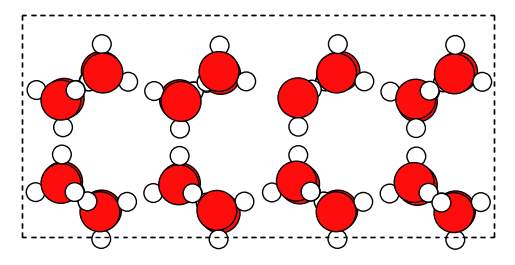

In [66]:
# defect_ice_block = ice_block
print(candidate_qm_water)
indecies = candidate_qm_water['WAT']
target = indecies[:3]
print(f'Target: {target}')
defect, up_candidate_qm_water = del_atoms_pdb(
    filename=PDB_FILE,
    output_filename=DEFECT_PDB_FILE,
    delete_indecies=target,
    qm_resname='LIG'
)

DEFECT_PDB_FILE
print('ATOMS deleted')
print(f'Defect {defect}')
print(f'New qm candidate list {up_candidate_qm_water}')

plot_atoms(read(filename=DEFECT_PDB_FILE))

Calculate new energy

In [60]:
import veloxchem.ensembledriver
import veloxchem.ensembleparser

ep = veloxchem.ensembleparser.EnsembleParser()   
ed = veloxchem.ensembledriver.EnsembleDriver()

print("1. \t Ensemble parser instance created.")

charge, multiplcity = calc_charge_multiplicity(filename=DEFECT_PDB_FILE, qm_resname='LIG', charge_map={'O':-2, 'H':1})
defect_scf_results = calc_energy_tot(
    filename=DEFECT_PDB_FILE, 
    qm_resname='LIG', 
    pe_cutoff=15.646, 
    npe_cutoff=None,
    qm_charge = charge,
    qm_multiplicity=multiplcity
    )

1. 	 Ensemble parser instance created.
Ensemble parser instance created.
                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock with PE                                 
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10           

Calcualte formation energy

In [81]:
calc_formation_energy(filename_perf=PDB_FILE, filename_defect=DEFECT_PDB_FILE, defect_type='molecular', molecule_len=3, defect=defect, qm_resname='LIG', atom_potentials={'H':1, 'O':1}, npe_cutoff=None, pe_cutoff=16.0, charge_map=CHARGE_MAP)

1.	CALCULATING PERFECT LATTICE CHARGE AND MULTIPLICITY
  	Charge: 0
  	Multiplicity: 1
2.	CALCULATING TOTAL ENERGY OF PERFECT LATTICE
Ensemble parser instance created.


/opt/anaconda3/envs/vlxenv/lib/python3.13/site-packages/MDAnalysis/core/universe.py:607: DeprecationWarning: Bond guessing through the `guess_bonds` keyword is deprecated and will be removed in MDAnalysis 3.0. Instead, pass 'bonds', 'angles', and 'dihedrals' to the `to_guess` keyword in Universe for guessing these if they are not present, or `force_guess` if they are and you wish to replace these bonds with guessed values. The kwargs `fudge_factor`, `vdwradii`, and `lower_bound` are also deprecated and will be removed in MDAnalysis 3.0, where they should be passed into the Context for guessing on Universe instantiation. If using guess_TopologyAttrs, pass these kwargs to the method instead, as they will override the previous Context values.
  warnings.warn(


                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock with PE                                 
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

np.float64(152.47326887154512)

Calculate energy difference

**Equation(S)**

**From* https://pubs.aip.org/aip/jap/article/95/8/3851/472904/First-principles-calculations-for-defects-and?guestAccessKey=*

$E^f[X^q]=E_{tot}[X^q]-E_{tot}[Mol,bulk]-\sum_i n_i µ_i+q[E_F+E_v+∂V]$

$E_{tot}[X]$ is total energy derived from supercell calcualtions with an inpurity introduced, where $X$ simply symbolizes the impurtity.

$E_{tot}[Mol,bulk]$ represents the correspnding total energy of the undisturbed lattice. 

$n_i$ is the number of atoms of each type that has been added or removed ($n_i<1$ in case of removal of particle). In some cases impurities are itnroduced as additional particles, in which case types i are the host particles and the inpurity. 

$µ_i$ is the corresponding chemical potential of these species. In case of the removal of a host particel, then µ_i is the chemcial potential of an individual host particle.

$E_F$ is the so called "Fermi level".

$E_V$ is the formation energy of charged states. How relevant this is for various different systems is out of my knowledge. 





In [ ]:
undistr_energy = scf_results['scf_all'][0][1]['scf_energy']
disturbed_energy = defect_scf_results['scf_all'][0][1]['scf_energy']
chemi_pot = chem_pot_scf_results['scf_all'][0][1]['scf_energy']

print(f'Energies: \n \t No Defect Lattice: {undistr_energy} \n \t Defect Lattice: {disturbed_energy}\n \t Diff: {disturbed_energy-undistr_energy+chemi_pot} Hartree or \n \t {(disturbed_energy-undistr_energy+chemi_pot)*27} eV/mol')

plot_atoms(read(PDB_FILE))
plot_atoms(read(DEFECT_PDB_FILE))

## Testing Point Defect in Ice 1h using SCF_driver (Draft)

In [ ]:
from veloxchem import scfdriver



## Testing Point Defects in NaCl (ionic and pair defects)

In [ ]:
from ase.build import bulk
from ase.spacegroup import crystal
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
from ase.io import read, write

In [ ]:
PATH = PATH
NACL_GENERAL_FILE_NAME = 'supercell_nacl'
# nacl = crystal(
#     symbols='NaCl', 
#     basis=[[0,0,0]],#, [0,1,0]],
#     spacegroup=227,
#     cellpar=[1,1,1, 90, 90, 90],
#     size=(2,2,2)
#     )

nacl = bulk('NaCl', 'rocksalt', a=3.57)

plot_atoms(nacl)

P = find_optimal_cell_shape(
    cell = nacl.cell,
    target_shape='sc',
    target_size=100
    )

supercell_nacl = make_supercell(nacl, P)

plot_atoms(supercell_nacl)

write(filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif', images=supercell_nacl, format='cif')

candidate_qm_nacl = get_centeroid_region(f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


In [ ]:
# Writes supercell to a file
write(filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)

# # Processes that file
# process_pdb(
#     filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
#     atoms_per_mol=1,
#     target_filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
#     qm_resname='LIG',
#     qm_indecies=candidate_qm_nacl,
#     global_resname=None,
#     atom_type_resnames={'NA':'NA', 'CL':'CL'}
# )

process_pdb(
    filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
    patterns={' NA':['Na'], ' CL':['Cl']},
    qm_ids=candidate_qm_nacl,
    qm_resname='LIG'
)


# Calculate qm_charge and multiplicity
supercell_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif')
np_supercell = np.array(supercell_nacl)

n = sum(1 for idx in candidate_qm_nacl if np_supercell[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_nacl if np_supercell[idx].symbol == 'Cl')
qm_charge = n - m

# Calculates supercell energy from the file
nacl_scf_results = calc_energy_tot(
    filename=f'{PATH}/{GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)

Del an ion

In [ ]:
# Define defect supercell file name
DEFECT_NACL_GENERAL_FILE_NAME = f'defect_{NACL_GENERAL_FILE_NAME}'

# Copy the undisturbed supercell
defect_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb')

# Delete one atom
del defect_nacl[77]

# Write the dsiturbed supercell to a new file:
write(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.cif', images=defect_nacl)
write(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=defect_nacl)

# Identify new qm_candidates (might be a logical bug here)
candidate_qm_defect_nacl = get_centeroid_region(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


# Process that pdb file. 
# write(filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)
process_pdb(
    filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    atoms_per_mol=1,
    target_filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_indecies=candidate_qm_defect_nacl,
    global_resname=None,
    atom_type_resnames={'NA':'NA', 'CL':'CL'}
)

# Calculate qm charge and multiplicity:
#_nacl = read(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb')
np_defect_nacl = np.array(defect_nacl)

n = sum(1 for idx in candidate_qm_defect_nacl if np_defect_nacl[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_defect_nacl if np_defect_nacl[idx].symbol == 'Cl')
qm_charge = n - m



In [ ]:
defect_nacl_scf_results = calc_tot_energy(
    filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)

In [ ]:
# Define defect supercell file name
PAIR_DEFECT_NACL_FILE_NAME = f'defect_{NACL_GENERAL_FILE_NAME}'

# Copy the undisturbed supercell
pair_defect_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb')

# Delete one atom
del pair_defect_nacl[76:77]

# Write the dsiturbed supercell to a new file:
write(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.cif', images=pair_defect_nacl)
write(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb', images=pair_defect_nacl)

# Identify new qm_candidates (might be a logical bug here)
candidate_qm_pair_defect_nacl = get_centeroid_region(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


# Process that pdb file. 
# write(filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)
process_pdb(
    filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    atoms_per_mol=1,
    target_filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_indecies=candidate_qm_pair_defect_nacl,
    global_resname=None,
    atom_type_resnames={'NA':'NA', 'CL':'CL'}
)

# Calculate qm charge and multiplicity:
#_nacl = read(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb')
np_pair_defect_nacl = np.array(pair_defect_nacl)

n = sum(1 for idx in candidate_qm_pair_defect_nacl if np_pair_defect_nacl[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_pair_defect_nacl if np_pair_defect_nacl[idx].symbol == 'Cl')
qm_charge = n - m

pair_defect_nacl_scf_results = calc_energy_tot(
    filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)



In [ ]:
undistr_energy = nacl_scf_results['scf_all'][0][1]['scf_energy']
disturbed_energy = defect_nacl_scf_results['scf_all'][0][1]['scf_energy']
pair_defect_energy = pair_defect_nacl_scf_results['scf_all'][0][1]['scf_energy']

print(f'Energies: \n \t No Defect Lattice: {undistr_energy} \n \t Defect Lattice: {disturbed_energy}\n \t Pair Defect Lattice: {pair_defect_energy} \n \n \t Diff (ionic point defect): {disturbed_energy-undistr_energy} Hartree or {(disturbed_energy-undistr_energy)*27} eV/mol \n \t Diff (Pair defect): {(pair_defect_energy-undistr_energy)} Hartree  or {(pair_defect_energy-undistr_energy)*27} eV/mol')
plot_atoms(supercell_nacl)
plot_atoms(defect_nacl)
plot_atoms(pair_defect_nacl)

## Defects in Benzene (Draft)

In [ ]:
BENZENE_FILE_NAME = 'benzene'
benzene = read(f'{PATH}/{BENZENE_FILE_NAME}.cif')
plot_atoms(benzene)

write(
    filename=f'{PATH}/{BENZENE_FILE_NAME}.pdb',
    images=benzene
    )

In [ ]:
# PROCESS PDB FILE MANUALLY PLEASE
#  process_pdb(
#     filename=f'{PATH}/{BENZENE_FILE_NAME}.pdb',
#     atoms_per_mol=
# )